# Data Checking 

In [26]:
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
from beir.datasets.data_loader import GenericDataLoader
from collections import Counter
from scipy.spatial.distance import jensenshannon
import numpy as np
import spacy
nlp = spacy.load("en_core_web_sm")

In [ ]:
# Original Data
data_dir = f"/work/mbouthil/datasets/msmarco" # _{old_dataset_name}"
corpus, queries, qrels = GenericDataLoader(data_folder=data_dir).load(split="train")
print(len(qrels))

100%|██████████| 8941823/8941823 [01:13<00:00, 121813.81it/s]


100000


In [56]:
for q_id, data in qrels.items():
    if len(data) > 3:
        data = dict([(p_id, score) for p_id, score in data.items() if score > 0])
        print(q_id)
        print(data)
        break

529690
{'686269': 1, '686270': 1, '686271': 1, '686273': 1, '686275': 1}


In [41]:
print(f"Qrels: {len(qrels)}")
print(f"Corpus: {len(corpus)}")
print(f"Queries: {len(queries)}")

Qrels: 100000
Corpus: 8941823
Queries: 100000


In [69]:
syn_dir = "/work/mbouthil/datasets/msmarco_sqfsa-v2"
loader = GenericDataLoader(data_folder=syn_dir)

### Checking Queries

In [70]:
loader._load_queries()
syn_queries = loader.queries

# print(len(syn_queries))
# print(list(syn_queries.values())[0])

counter = 0
syn_q_text = set(list(syn_queries.values())[:100000])
for q_id, query  in queries.items():
    if query in syn_q_text:
        # print(query)
        # print(q_id)
        # print("Queries are from original dataset--are not synthetic")
        counter +=1 
print(counter)
print(f"Queries: {len(syn_queries)}")

629
Queries: 100012


In [36]:
counter/100_000*100

0.629

In [63]:
print(list(syn_queries.values())[0])
print(list(queries.values())[0])

what was the cloud hanging over the success of the Manhattan Project
when is  the most expensive time  to go to punta cana


### Checking qrels

In [68]:
loader.qrels_file = os.path.join(loader.qrels_folder, "train.tsv")
loader._load_qrels()
syn_qrels = loader.qrels

# for syn_qrel in syn_qrels:
#     if syn_qrel not in qrels:
#         raise "Syn qrels missing"
    
print(len(syn_qrels))

100000


### Checking Corpus

In [20]:
loader._load_corpus()
syn_corpus = loader.corpus

 54%|█████▍    | 4861316/8941823 [00:40<00:33, 120885.84it/s]


KeyboardInterrupt: 

In [95]:
print(len(syn_corpus) - len(corpus))

100000


In [96]:
original_passages = set(passage['text'] for passage in corpus.values())

for passage in syn_corpus.values():
    if passage['text'] not in original_passages:
        print("Synthetic (negative) passages included")
        break

Synthetic (negative) passages included


# Result modeling script

In [ ]:
# Gathering all Loss df
df = pd.DataFrame()

for file in os.listdir('/work/mbouthil/MMATH-CM-Research-Project/results'):
    file_path = os.path.join('/work/mbouthil/MMATH-CM-Research-Project/results', file)
    if 'loss' in file_path:
        df = pd.concat([df, pd.read_csv(file_path)], axis=1)

loss_df = df
loss_df.to_csv(f"/work/mbouthil/MMATH-CM-Research-Project/results/all_loss.csv", index=False)

In [ ]:
# Formating
model_types='''r400s_base
r400s_sq
r400s_sq-
r400s_sqa
r400s_sqa-
r400s_sqa2
r400s_sqa2-

r400s_sqfs
r400s_sqfs-
r400s_sqfsa
r400s_sqfsa-

r400s_sq-v2
r400s_sq-v3
r400s_sq-fs'''

model_types = [model[6:] for model in model_types.split("\n") if len(model)> 0]

In [ ]:
data_dir = "/work/mbouthil/datasets/msmarco"


TypeError: GenericDataLoader._load_qrels() got an unexpected keyword argument 'split'

In [ ]:
data_dir = "/work/mbouthil/datasets/msmarco"
loader = GenericDataLoader(data_folder=data_dir)
loader._load_queries()

loader.qrels_file = os.path.join(loader.qrels_folder, "train.tsv")
loader._load_qrels()

queries = loader.queries
qrels = loader.qrels

In [ ]:
data_dir = "/work/mbouthil/datasets/msmarco"
loader = GenericDataLoader(data_folder=data_dir)
loader._load_queries()

loader.qrels_file = os.path.join(loader.qrels_folder, "train.tsv")
loader._load_qrels()

queries = loader.queries
qrels = loader.qrels

In [ ]:
list(queries.values())[0]

')what was the immediate impact of the success of the manhattan project?'

In [ ]:
def tokenize_corpus(corpus, stop_words=None):
    tokens = []
    for doc in corpus:
        for word in doc.split():
            if stop_words and word.lower() in stop_words:
                continue
            tokens.append(word.lower())
    return tokens

def relative_freq(tokens):
    counts = Counter(tokens)
    total = sum(counts.values())
    return {w:c/total for w,c in counts.items()}

In [ ]:
def get_js_div(queries, syn_queries):
    all_queries = list(queries.values()) + list(syn_queries.values())
    words = set([word
        for query in all_queries
        for word in query.split()])
    stop_words = set([stop_word for stop_word in words if stop_word in nlp.Defaults.stop_words])

    q_tokens = tokenize_corpus(list(queries.values()), stop_words=stop_words)
    synq_tokens = tokenize_corpus(list(syn_queries.values()), stop_words=stop_words)

    q_dist = relative_freq(q_tokens)
    synq_dist = relative_freq(synq_tokens)

    vocab = sorted(set(q_dist.keys()).union(synq_dist.keys()))
    vec = np.array([q_dist.get(w,0) for w in vocab])
    syn_vec = np.array([synq_dist.get(w,0) for w in vocab])

    return jensenshannon(vec, syn_vec)

In [ ]:
for model in model_types[1:]:
    dataset_name = f'_syn_{model[1:]}'
    print(dataset_name)

_syn_q
_syn_q-
_syn_qa
_syn_qa-
_syn_qa2
_syn_qa2-
_syn_qfs
_syn_qfs-
_syn_qfsa
_syn_qfsa-
_syn_q-v2
_syn_q-v3
_syn_q-fs


In [ ]:
# Calculating JS Divergence of each subset with original data
# for model in model_types[1:2]:
dataset_name = f'_syn_q_CORRECTED'
print(dataset_name)
new_dir = data_dir + dataset_name

loader = GenericDataLoader(data_folder=new_dir)
loader._load_queries()

loader.qrels_file = os.path.join(loader.qrels_folder, "train.tsv")
loader._load_qrels()

syn_queries = loader.queries
syn_qrels = loader.qrels

js = get_js_div(queries, syn_queries)
print(js)

_syn_q_CORRECTED
0.4678398382278154


In [ ]:
results={}

for model in model_types:
    results[str(model)] = {}
    for file in os.listdir('/work/mbouthil/MMATH-CM-Research-Project/results'):
        file_path = os.path.join('/work/mbouthil/MMATH-CM-Research-Project/results', file)
        if str(model) == file_path.split('_')[1] and 'loss' not in file_path:
            data = pd.read_csv(file_path).iloc[0].to_dict()
            model_type = f"{file_path[50:53]}_steps"
            results[str(model)][str(model_type)] = data

with open("/work/mbouthil/MMATH-CM-Research-Project/results/all_results.json", "w") as f:
    json.dump(results, f, indent=2)

# Modeling Results

In [ ]:
with open("/work/mbouthil/MMATH-CM-Research-Project/results/all_results.json") as f:
    results = json.load(f)

In [ ]:
results

{'base': {'400_steps': {'NDCG@10': 0.27328,
   'MRR@10': 0.22244,
   'Recall@100': 0.73295,
   'Recall@1000': 0.73295},
  '800_steps': {'NDCG@10': 0.29051,
   'MRR@10': 0.23755,
   'Recall@100': 0.76388,
   'Recall@1000': 0.92467}},
 'sq': {'400_steps': {'NDCG@10': 0.18297,
   'MRR@10': 0.14648,
   'Recall@100': 0.58883,
   'Recall@1000': 0.81953},
  '800_steps': {'NDCG@10': 0.19247,
   'MRR@10': 0.15192,
   'Recall@100': 0.61437,
   'Recall@1000': 0.84208}},
 'sq-': {'400_steps': {'NDCG@10': 0.27371,
   'MRR@10': 0.22239,
   'Recall@100': 0.73426,
   'Recall@1000': 0.90663},
  '800_steps': {'NDCG@10': 0.28348,
   'MRR@10': 0.23015,
   'Recall@100': 0.75288,
   'Recall@1000': 0.9211}},
 'sqa': {'400_steps': {'NDCG@10': 0.19,
   'MRR@10': 0.15147,
   'Recall@100': 0.61837,
   'Recall@1000': 0.84094},
  '800_steps': {'NDCG@10': 0.19818,
   'MRR@10': 0.15823,
   'Recall@100': 0.63259,
   'Recall@1000': 0.85628}},
 'sqa-': {'400_steps': {'NDCG@10': 0.26933,
   'MRR@10': 0.21958,
   'Recall

In [ ]:
for model in results.keys():
    print(results[model])
    break

{'400_steps': {'NDCG@10': 0.27328, 'MRR@10': 0.22244, 'Recall@100': 0.73295, 'Recall@1000': 0.73295}, '800_steps': {'NDCG@10': 0.29051, 'MRR@10': 0.23755, 'Recall@100': 0.76388, 'Recall@1000': 0.92467}}


In [ ]:
print(len(results.keys()))

14


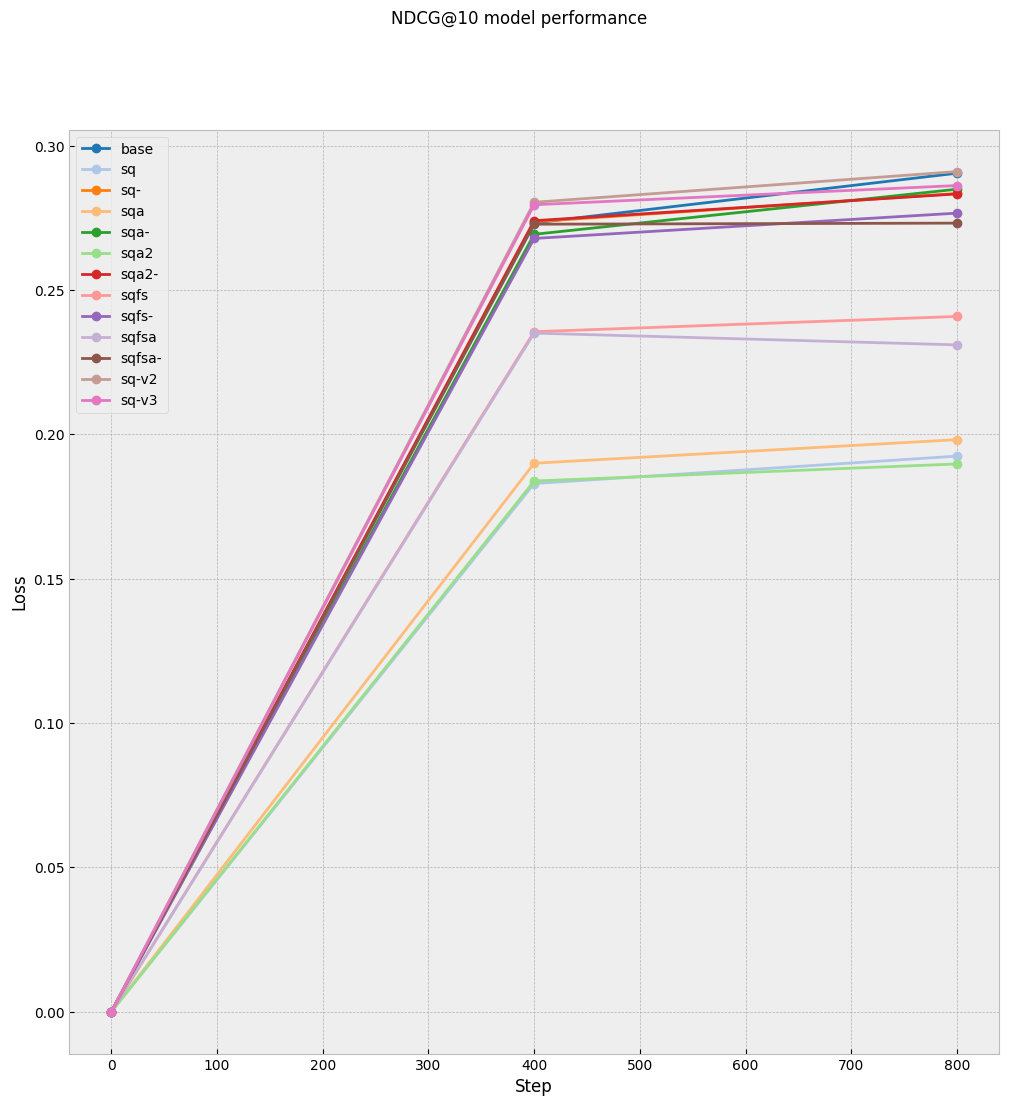

In [ ]:
metric='NDCG@10'

plt.style.use('bmh')
plt.figure(figsize=(12, 12))
plt.suptitle(f"{metric} model performance")

colors = plt.cm.tab20.colors[:len(results.keys())-1]

for i, model in enumerate(list(results.keys())[:-1]):
    x = [0, 400, 800]
    y = [0, results[model]['400_steps'][metric], results[model]['800_steps'][metric]]
    plt.plot(x, y, 'o', linestyle="-", label=str(model), color=colors[i])


# plt.yscale('log')
plt.ylabel("Loss")
plt.xlabel("Step")
plt.legend()
plt.show()

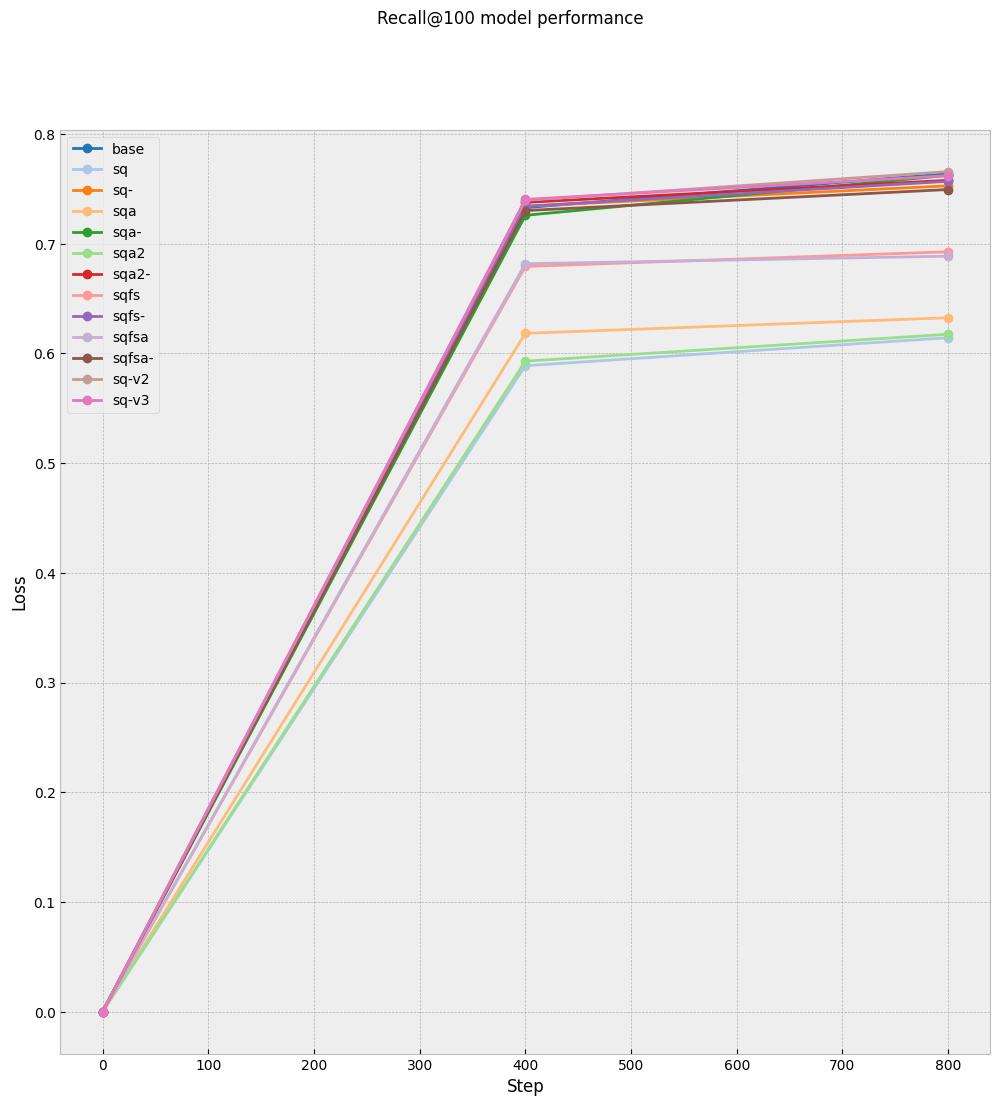

In [ ]:
metric='Recall@100'

plt.style.use('bmh')
plt.figure(figsize=(12, 12))
plt.suptitle(f"{metric} model performance")

colors = plt.cm.tab20.colors[:len(results.keys())-1]

for i, model in enumerate(list(results.keys())[:-1]):
    x = [0, 400, 800]
    y = [0, results[model]['400_steps'][metric], results[model]['800_steps'][metric]]
    plt.plot(x, y, 'o', linestyle="-", label=str(model), color=colors[i])


# plt.yscale('log')
plt.ylabel("Loss")
plt.xlabel("Step")
plt.legend()
plt.show()

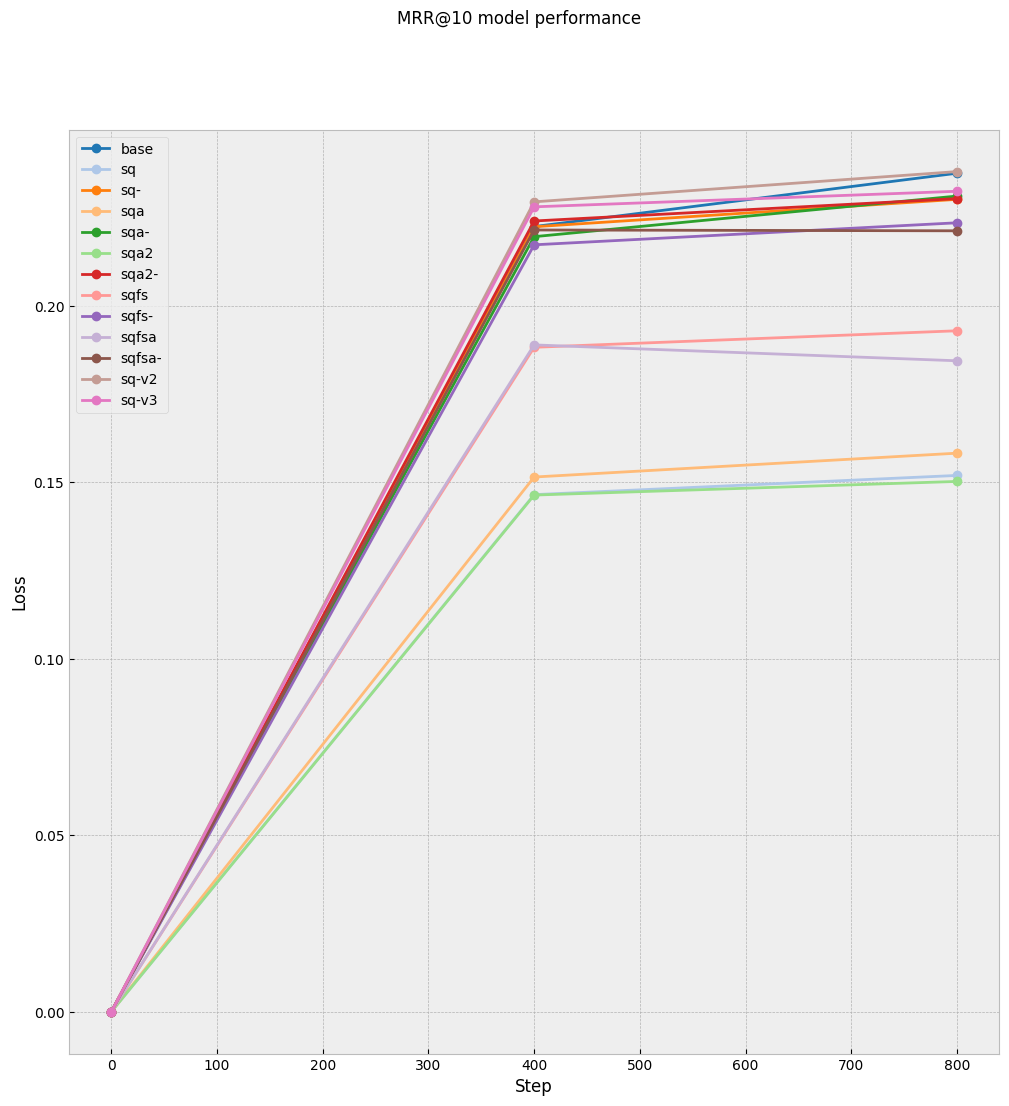

In [ ]:
metric='MRR@10'

plt.style.use('bmh')
plt.figure(figsize=(12, 12))
plt.suptitle(f"{metric} model performance")

colors = plt.cm.tab20.colors[:len(results.keys())-1]

for i, model in enumerate(list(results.keys())[:-1]):
    x = [0, 400, 800]
    y = [0, results[model]['400_steps'][metric], results[model]['800_steps'][metric]]
    plt.plot(x, y, 'o', linestyle="-", label=str(model), color=colors[i])


# plt.yscale('log')
plt.ylabel("Loss")
plt.xlabel("Step")
plt.legend()
plt.show()

# Proper Copying

In [ ]:
import shutil
import os
syn_q_name='syn_q'
passage_data_name=syn_q_name + '-v2'
cor_dataset_name = passage_data_name+'_CORRECTED'


# Creating directories
query_dir = f"/work/mbouthil/datasets/msmarco_{syn_q_name}"
passage_dir = f"/work/mbouthil/datasets/msmarco_{passage_data_name}"
new_dir = f"/work/mbouthil/datasets/msmarco_{cor_dataset_name}"
os.makedirs(new_dir, exist_ok=True)
os.makedirs(os.path.join(new_dir, "qrels"), exist_ok=True)

# Copying queries
shutil.copy(
    f"{query_dir}/queries.jsonl", 
    f"{new_dir}/queries.jsonl"
)

# Copying passages
shutil.copy(
    f"{passage_dir }/corpus.jsonl", 
    f"{new_dir}/corpus.jsonl"
)

qrels_path = os.path.join(passage_dir, "qrels", "train.tsv")
new_qrels_path = os.path.join(new_dir, "qrels", "train.tsv")
# Copying qrels
shutil.copy(qrels_path, new_qrels_path)

'/work/mbouthil/datasets/msmarco_syn_q-v2_CORRECTED/qrels/train.tsv'